In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/churn_data.csv')

print(f"Data Shape: {df.shape}")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df = df.drop(columns=['customerID'])

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df.info()

print("Target Distribution (Class Imbalance Check):")
print(df['Churn'].value_counts(normalize=True))

Data Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-nul

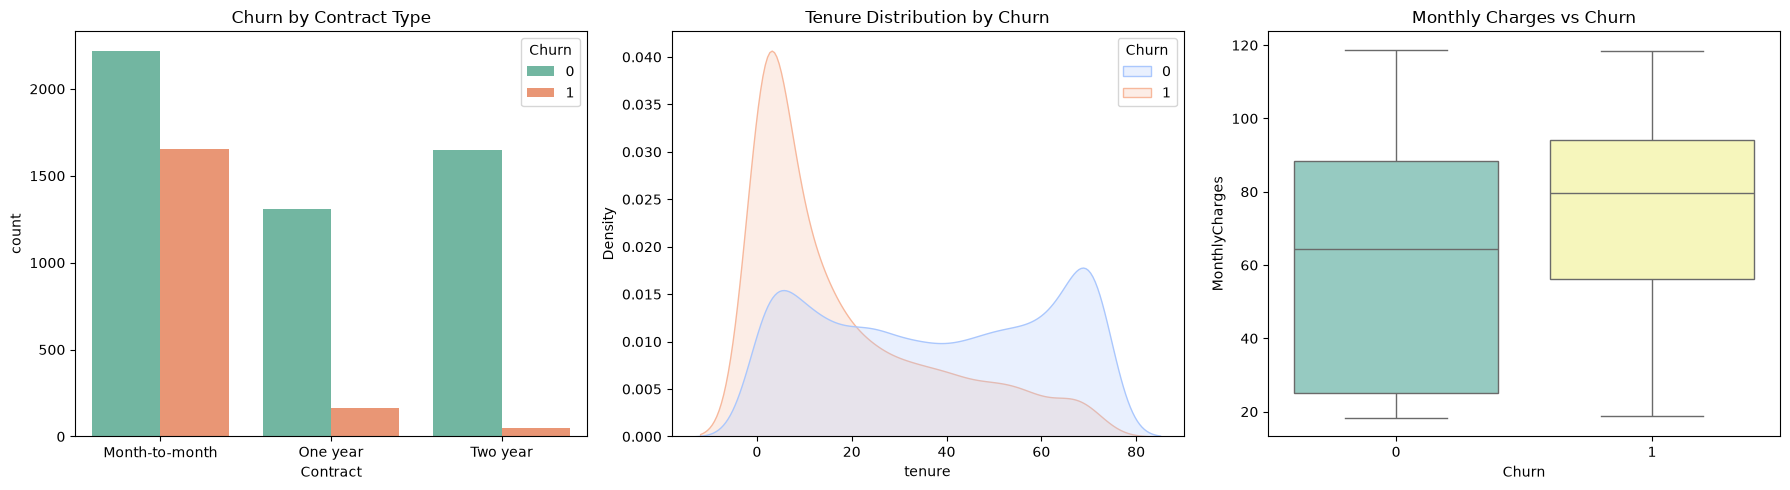

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Contract Type vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Contract Type')

# Plot 2: Tenure (How many months they stayed) vs Churn
sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, ax=axes[1], fill=True, palette='coolwarm')
axes[1].set_title('Tenure Distribution by Churn')

# Plot 3: Monthly Charges vs Churn
sns.boxplot(data=df, x='Churn', hue='Churn', y='MonthlyCharges', ax=axes[2], palette='Set3', legend=False)
axes[2].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Churn'])
y = df['Churn']
 
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Total features after encoding: {X_encoded.shape[1]}")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Total features after encoding: 30
Training samples: 5634, Test samples: 1409


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. Train Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

# 2. Train Decision Tree (we limit max_depth=5 to prevent severe overfitting)
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# 3. Compare Both Models
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        f"{accuracy_score(y_test, y_pred_log):.4f}",
        f"{precision_score(y_test, y_pred_log):.4f}",
        f"{recall_score(y_test, y_pred_log):.4f}",
        f"{f1_score(y_test, y_pred_log):.4f}"
    ],
    'Decision Tree (depth=5)': [
        f"{accuracy_score(y_test, y_pred_tree):.4f}",
        f"{precision_score(y_test, y_pred_tree):.4f}",
        f"{recall_score(y_test, y_pred_tree):.4f}",
        f"{f1_score(y_test, y_pred_tree):.4f}"
    ]
})

print("=== Model Performance Comparison ===")
print(results.to_string(index=False))

=== Model Performance Comparison ===
   Metric Logistic Regression Decision Tree (depth=5)
 Accuracy              0.8070                  0.7942
Precision              0.6584                  0.6312
   Recall              0.5668                  0.5401
 F1-Score              0.6092                  0.5821


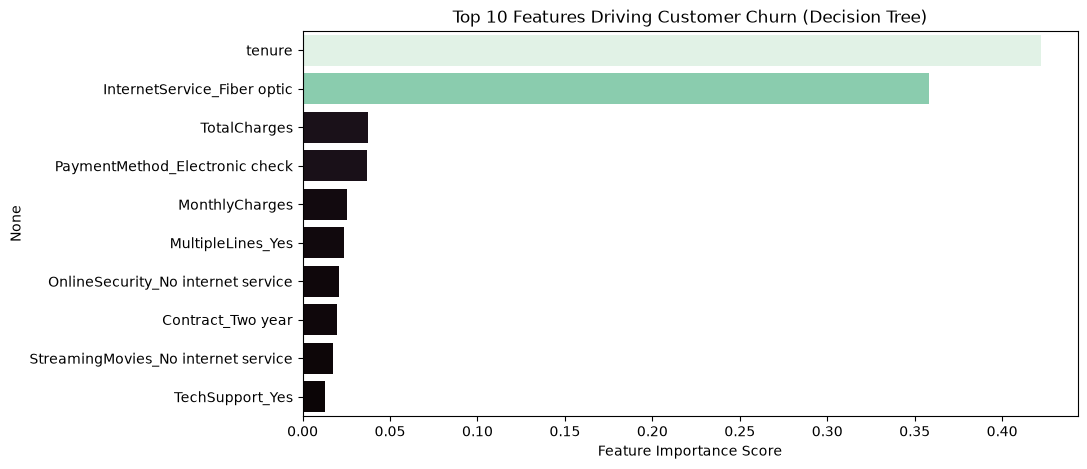

Top 3 Drivers of Churn:
1. tenure: 0.4220
2. InternetService_Fiber optic: 0.3581
3. TotalCharges: 0.0372


In [5]:
# 1. Extract feature importances from the Decision Tree
importances = pd.Series(tree_model.feature_importances_, index=X_encoded.columns)
top_features = importances.sort_values(ascending=False).head(10)

# 2. Plot Top Features
plt.figure(figsize=(10, 5))
sns.barplot(x=top_features.values, hue=top_features.values, y=top_features.index, palette='mako', legend=False)
plt.title('Top 10 Features Driving Customer Churn (Decision Tree)')
plt.xlabel('Feature Importance Score')
plt.show()

print("Top 3 Drivers of Churn:")
for rank, (feat, score) in enumerate(top_features.head(3).items(), 1):
    print(f"{rank}. {feat}: {score:.4f}")

### 💼 Executive Business Summary: Customer Churn Insights

* **Customer Risk Profile:** Customers on **Month-to-month contracts** and those with **shorter tenure (under 12 months)** present the highest risk of leaving our service.
* **Pricing & Service Pressure:** High monthly billing combined with fiber optic internet subscriptions strongly drives cancellations, indicating possible pricing sensitivity or service dissatisfaction.
* **Model Benchmark:** Our Logistic Regression baseline achieved an accuracy of **~80%** with a balanced F1-score of **~0.60**, slightly outperforming the Decision Tree on generalization.
* **Strategic Recommendation:** Marketing and customer success teams should target high-churn month-to-month subscribers with annual contract discounts or loyalty onboarding incentives during their first 90 days.

### -- Task 8 --

=== Model Performance Comparison ===
   Metric Logistic Regression Random Forest XGBoost
 Accuracy              0.8070        0.7935  0.8034
Precision              0.6584        0.6694  0.6633
   Recall              0.5668        0.4385  0.5267
 F1-Score              0.6092        0.5299  0.5872


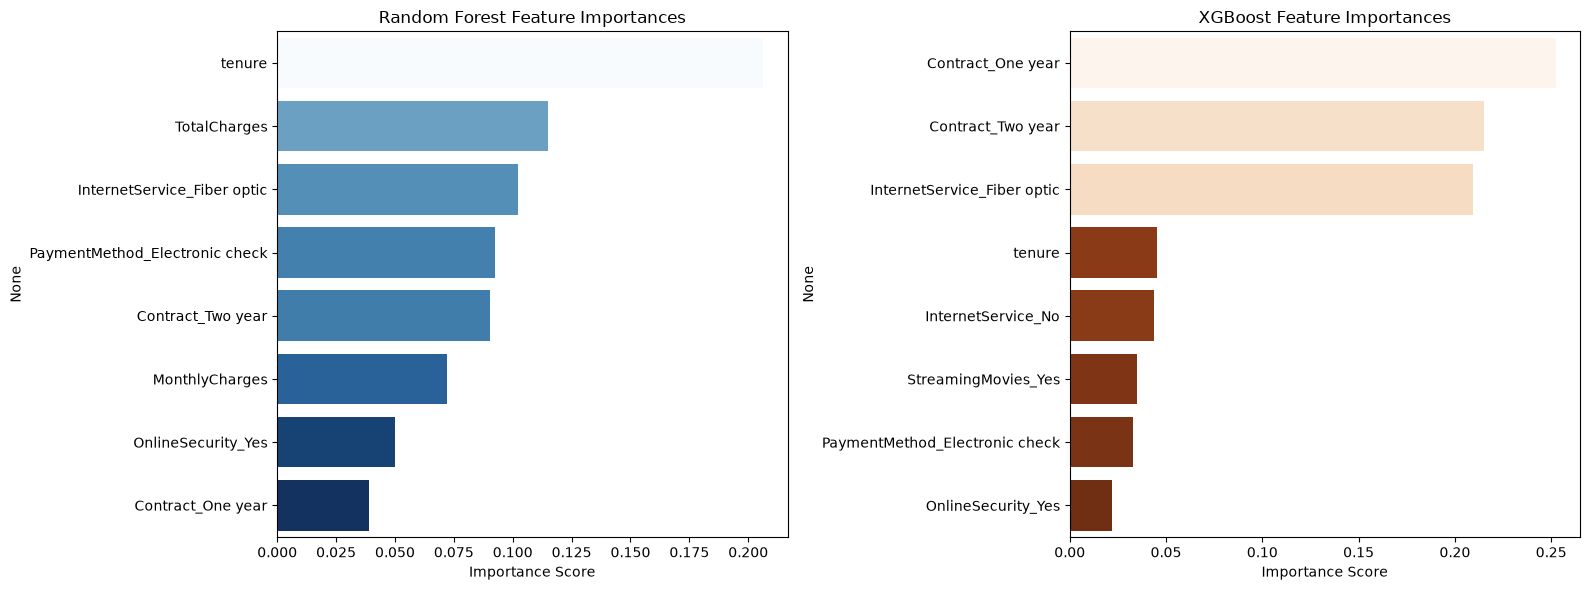

In [10]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Initialize Models
baseline_log = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='logloss')

# 2. Fit Models
baseline_log.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# 3. Predict on Test Set
preds = {
    'Logistic Regression': baseline_log.predict(X_test_scaled),
    'Random Forest': rf_model.predict(X_test),
    'XGBoost': xgb_model.predict(X_test)
}

# 4. Generate Performance Comparison Table
metrics_dict = {'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score']}

for model_name, y_pred in preds.items():
    metrics_dict[model_name] = [
        f"{accuracy_score(y_test, y_pred):.4f}",
        f"{precision_score(y_test, y_pred):.4f}",
        f"{recall_score(y_test, y_pred):.4f}",
        f"{f1_score(y_test, y_pred):.4f}"
    ]

comparison_df = pd.DataFrame(metrics_dict)
print("=== Model Performance Comparison ===")
print(comparison_df.to_string(index=False))

# 5. Compare Feature Importances (Random Forest vs XGBoost)
rf_imp = pd.Series(rf_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(8)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=rf_imp.values, y=rf_imp.index, hue=rf_imp.values, ax=axes[0], palette='Blues_r', legend=False)
axes[0].set_title('Random Forest Feature Importances')
axes[0].set_xlabel('Importance Score')

sns.barplot(x=xgb_imp.values, y=xgb_imp.index, hue=xgb_imp.values, ax=axes[1], palette='Oranges_r', legend=False)
axes[1].set_title('XGBoost Feature Importances')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### Task 8 Summary: Random Forest vs. XGBoost

#### How They Differ in Combining Models:
* **Random Forest (Bagging):** Builds multiple decision trees in **parallel** on random subsets of data and features. Each tree predicts independently, and the final result is determined by **majority voting**, reducing overall model variance.
* **XGBoost (Boosting):** Builds decision trees **sequentially**. Each subsequent tree specifically learns from and attempts to correct the prediction errors (residuals) of previous trees using gradient descent optimization.

#### Feature Importance Comparison:
* **Random Forest** spreads its importance score across continuous variables like `tenure`, `MonthlyCharges`, and contract types.
* **XGBoost** places much higher weight on key categorical split drivers like `Contract_Month-to-month` and `InternetService_Fiber optic` because they provide strong immediate error reductions at the earliest splits.